In [53]:
# Advanced Regression Models:
# 1. polynomial regression
# 2. Regularized regression models

In [54]:
# polynomial regression for modeling non-linear relationships

# polynomial regression is an extension of linear regression that models non-linear relationships by introducing higher-order terms of the i/p features.

# polynomial regression: It is a form of linear regression in which the relationship between the independent variable x and dependent variable y is modeled as an nth degree polynomial.
    # in typical linear regression:
        #  y=beta_0 + beta_1 * x + epsilon

    # in polynomial regression, we extend this to include higher-order terms:
        # y=beta_0 + beta_1 * x + beta_2 * x^2 + beta_3 * x^3+....+ beta_n * x^n + epsilon

    # this inclusion of higher-order terms allows the model to capture non-linear relationships between the features and the target variable.

# Steps in polynomial regression:
    # 1.feature Transformation: Create a polynomial from the original features
        # ex: x -> x^2, x^3, x^4
        # this is done using the PolynomialFeatures class from sklearn.preprocessing

    # 2.model training: perform: linear regression on the transformed features
    # 3.prediction: make predictions using the trained model
    # 4.evaluation: assess the model's performance or ability to capture non-linear relationships

    # Advantages of these steps:
        # 1. Flexibility: can model a wide range of non-linear relationships
        # 2. Simplicity: can be implemented using existing linear regression models
        # 3. Interpretability: the relationship between features and target is linear

# limitations of these steps:
    # 1. Overfitting: higher-order terms can lead to overfitting if not properly regularized
    # 2. Interpretability: higher-order terms can make the model less interpretable
    # 3. Computationally expensive: higher-order terms can increase the computational cost of training and prediction
    # -may require regularization techniques to prevent overfitting

Mean Squared Error: 19.429841658755922


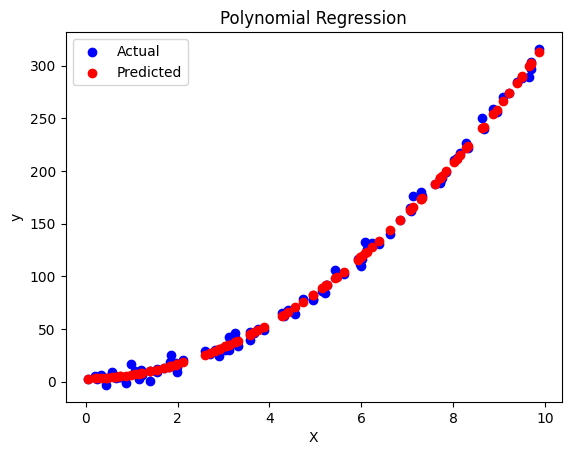

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 3 * X**2 + 2 * X + np.random.randn(100,1) * 5

# transform features to include higher-order terms
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# fit the model
model = LinearRegression()
model.fit(X_poly, y)

# make predictions
y_pred = model.predict(X_poly)

# evaluate the model
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

# plot the results
plt.scatter(X, y, color='blue', label='Actual')
plt.scatter(X, y_pred, color='red', label='Predicted')
plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()  

Mean Squared Error: 28.1939


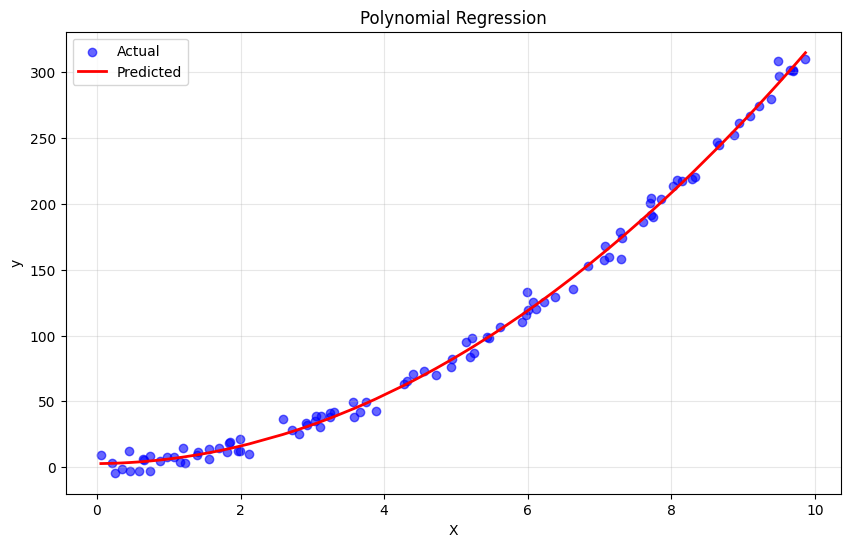


Model Coefficients:
Intercept: 2.7242
Coefficients (X, X²): [0.33042598 3.17202576]


In [56]:

y = (3 * X**2 + 2 * X + np.random.randn(100, 1) * 5).ravel()  # Fixed: Added ravel() and fixed random shape

# transform features to include higher-order terms
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# fit the model
model = LinearRegression()
model.fit(X_poly, y)

# make predictions
y_pred = model.predict(X_poly)

# evaluate the model
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual')

# Sort X for smooth line plotting
X_sorted = np.sort(X, axis=0)
X_sorted_poly = poly_features.transform(X_sorted)
y_pred_sorted = model.predict(X_sorted_poly)
plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label='Predicted')

plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print model coefficients
print(f"\nModel Coefficients:")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients (X, X²): {model.coef_}")


In [57]:
# Introduction to Regularization Techniques: Lasso and Ridge Regression

# Regularization is a technique used to prevent overfitting in machine learning models by adding a penalty term to the loss function.

# Types of Regularization:
    # 1. Lasso Regression(L1 Regularization): Adds the sum of the absolute value of coefficients to the cost function
        # -J(beta)=1/n * sum(yi-yi^)^2 + lambda * sum(|beta_j|) for i=1 to n and j=1 to p
        # -lambda:controls the strength of regularization
        # -Lasso Regression can lead to sparse models where some coefficients become exactly zero
        # -Lasso Regression is useful for feature selection
        # -Lasso Regression is less sensitive to outliers than Ridge Regression
        # -Lasso Regression is more sensitive to the choice of lambda than Ridge Regression

    # 2. Ridge Regression(L2 Regularization):Adds the sum of squared coefficients to the cost function
        # -J(beta)=1/n * sum(yi-yi^)^2 + lambda * sum(beta_j^2) for i=1 to n and j=1 to p
        # -lambda:controls the strength of regularization
        # -Ridge Regression is less sensitive to the choice of lambda than Lasso Regression
        # -Ridge Regression is more sensitive to outliers than Lasso Regression
        # -Ridge Regression is useful for feature selection

    # 3. Elastic Net:Combines L1 and L2 regularization
        # -J(beta)=1/n * sum(yi-yi^)^2 + lambda * sum(|beta_j|) + lambda * sum(beta_j^2) for i=1 to n and j=1 to p
        # -lambda:controls the strength of regularization
        # -Elastic Net is less sensitive to the choice of lambda than Lasso Regression
        # -Elastic Net is more sensitive to outliers than Lasso Regression
        # -Elastic Net is useful for feature selection

# key differences between Lasso and Ridge Regression:
    # 1. Lasso Regression can lead to sparse models where some coefficients become exactly zero
    # 2. Ridge Regression is less sensitive to the choice of lambda than Lasso Regression
    # 3. Ridge Regression is more sensitive to outliers than Lasso Regression
    # 4. Ridge Regression is useful for feature selection

In [58]:
# Avoiding Overfitting with Regularization

# -regularization reduces the risk of overfitting by controlling the complexity of the model.
# -the regularization parameter lambda(also called alpha in some libraries) plays a critical role:
    # -A high lambda value increases the penalty on the model complexity, leading to simpler models, forcing smaller coefficients and reducing overfitting.
    # -A low lambda value allows for more complex models with higher flexibility, model to fit the training data more closely, but increasing the risk of overfitting.

In [59]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 3 * X**2 + 2 * X + np.random.randn(100,1) * 5

# transform features to include higher-order terms
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# fit the model
# Ridge Regression
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Lasso Regression
model = Lasso(alpha=1.0)
model.fit(X_train, y_train)

# make predictions
ridge_pred = model.predict(X_test)
lasso_pred = model.predict(X_test)

# evaluate the model
ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print(f"Ridge Regression MSE: {ridge_mse}")
print(f"Lasso Regression MSE: {lasso_mse}")

# visualize 




Ridge Regression MSE: 16.092254841965275
Lasso Regression MSE: 16.092254841965275


In [60]:
# excerise

Mean Squared Error:  0.7032732680932144


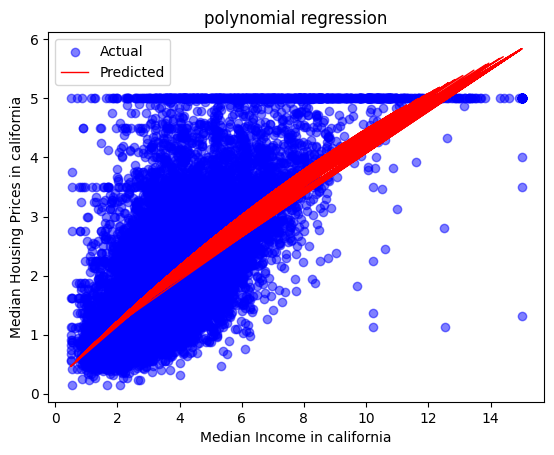

In [61]:
# 1.implement polynomial regression and visualize the fit 
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load the dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data[['MedInc']]
y = housing.target

# split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create a polynomial features object
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# fit the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# make predictions
y_pred = model.predict(X_test_poly)

# evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)


# plot Median Income vs Median Housing Prices
plt.scatter(X_train,y_train, color='blue', label='Actual',alpha=0.5)
plt.plot(X_test,y_pred, color='red', label='Predicted',linewidth=1)
plt.xlabel("Median Income in california")
plt.ylabel("Median Housing Prices in california")
plt.title("polynomial regression")
plt.legend()
plt.show()


       MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
0      8.3252      41.0  6.984127  ...     37.88    -122.23        4.526
1      8.3014      21.0  6.238137  ...     37.86    -122.22        3.585
2      7.2574      52.0  8.288136  ...     37.85    -122.24        3.521
3      5.6431      52.0  5.817352  ...     37.85    -122.25        3.413
4      3.8462      52.0  6.281853  ...     37.85    -122.25        3.422
...       ...       ...       ...  ...       ...        ...          ...
20635  1.5603      25.0  5.045455  ...     39.48    -121.09        0.781
20636  2.5568      18.0  6.114035  ...     39.49    -121.21        0.771
20637  1.7000      17.0  5.205543  ...     39.43    -121.22        0.923
20638  1.8672      18.0  5.329513  ...     39.43    -121.32        0.847
20639  2.3886      16.0  5.254717  ...     39.37    -121.24        0.894

[20640 rows x 9 columns]
Mean Squared Error: 0.695037253723973


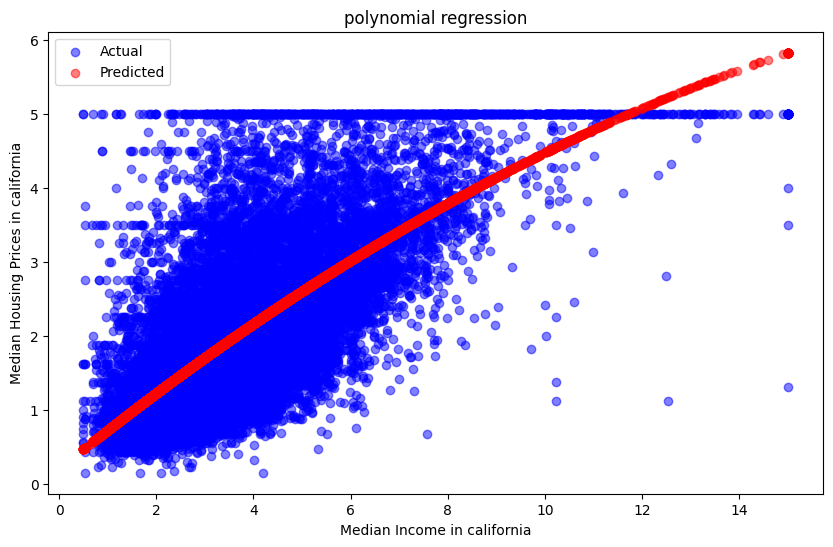

In [62]:

# Load the dataset
housing = fetch_california_housing(as_frame=True)
df=housing.frame
print(df)
# Select features(median income) and target variable(Median housing prices)

X=df[['MedInc']]
y=df[['MedHouseVal']]

# Transform features into a higher degree polynomial
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)

# Train a linear regression model on the transformed features
model=LinearRegression()
model.fit(X_poly,y)

# Make predictions
y_pred=model.predict(X_poly)

# evaluate the model
mse=mean_squared_error(y,y_pred)
print(f"Mean Squared Error: {mse}")

# plot actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(X,y, color='blue', label='Actual',alpha=0.5)
plt.scatter(X,y_pred, color='red', label='Predicted',alpha=0.5)
plt.xlabel("Median Income in california")
plt.ylabel("Median Housing Prices in california")
plt.title("polynomial regression")
plt.legend()
plt.show()

Lasso MSE: 0.7104136268779934
Ridge MSE: 0.7091157417310108


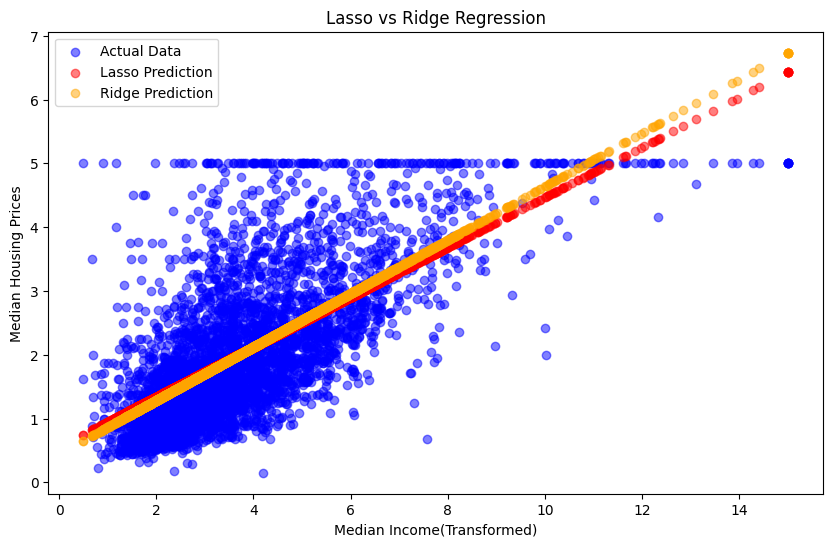

In [ ]:
# 2.Use lasso and ridge regression 
from sklearn.linear_model import Lasso, Ridge 
import matplotlib.pyplot as plt

# train on lasso and ridge regression models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the regularized models

# Lasso model with regression and prediction
lasso_model= Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Ridge model with regression and prediction
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Evaluate the models
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)

print("Lasso MSE:", lasso_mse)
print("Ridge MSE:", ridge_mse)

# visualization ridge vs lasso prediction
plt.figure(figsize=(10,6))
plt.scatter(X_test,y_test,color='blue',label='Actual Data',alpha=0.5)
plt.scatter(X_test,y_pred_lasso,color='red',label='Lasso Prediction',alpha=0.5)
plt.scatter(X_test,y_pred_ridge,color='orange',label='Ridge Prediction',alpha=0.5)
plt.title("Lasso vs Ridge Regression")
plt.xlabel("Median Income(Transformed)")
plt.ylabel("Median Housing Prices")
plt.legend()
plt.show()



Mean Squared Error:  0.7091157771765548


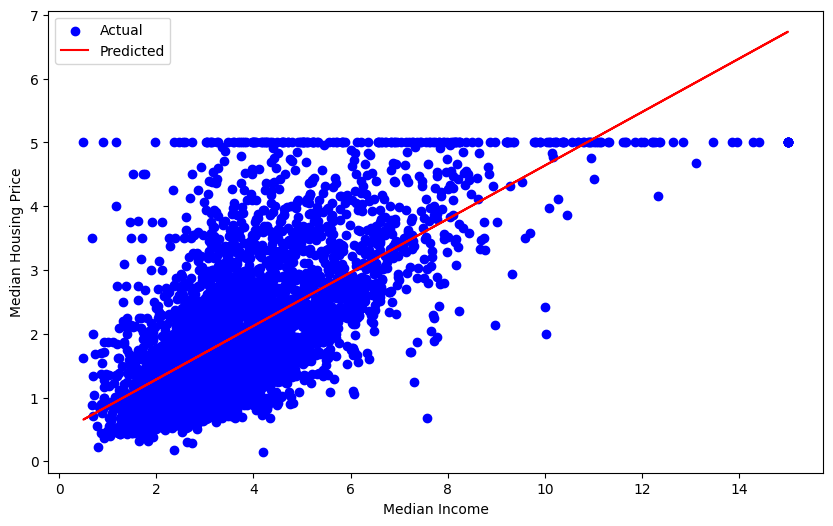

Linear Model Coefficients:
Coef:  [0.41933849]
Intercept:  0.44459729169078677
slope:  0.4193384939381274


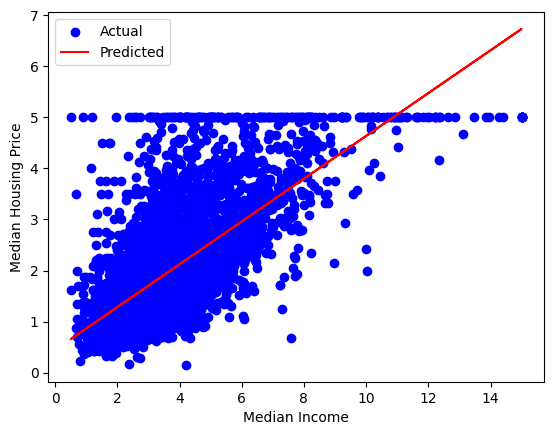

In [83]:
# observe how the model coefficients and performance change

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

# load the dataset
housing = fetch_california_housing(as_frame=True)

# select one feature for visualization (Median Income)
X = housing.data[['MedInc']]
y = housing.target

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# make predictions on the test set
y_pred = model.predict(X_test)

# evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)

# plot the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Median Income')
plt.ylabel('Median Housing Price')
plt.legend()
plt.show()

# Coefficients of the linear model
print("Linear Model Coefficients:")
print("Coef: ",model.coef_)
print("Intercept: ",model.intercept_)
print("slope: ",model.coef_[0])

# plot the linear regression line
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Median Income')
plt.ylabel('Median Housing Price')
plt.legend()
plt.show()